In [2]:
%pip install geopandas fiona shapely pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 10.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [fiona]32m2/3 [fiona]

[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import geopandas as gpd

path = "/Users/colelacroix/Documents/siuslaw.gpkg"

# list the layers in the geopackage first, since a .gpkg can hold multiple
import fiona
print(fiona.listlayers(path))

# then read the one you want (adjust layer= if there's more than one)
gdf = gpd.read_file(path)

print(gdf.crs)
gdf.head()

['s_usabdydesg_lsrs_nationalforestsystemlandunit']
EPSG:4269


,NFSLANDUNI,NFSLANDU_1,NFFID,NFSLANDU_2,GIS_ACRES,EFFECTIVED,EXPIRATION,HQ_LOCATIO,COMMENTS,REGION,SHAPE_AREA,SHAPE_LEN,geometry
0,295463010328,National Forest,0431,Siuslaw National Forest,832463.327,NaT,NaT,"Corvallis, OR",None,06,0.380465,18.035882,"MULTIPOLYGON (((-124.06275 44.29943, -124.0626..."


In [4]:
import ee
import geemap

In [5]:
ee.Authenticate()
ee.Initialize(project="fundamentals-of-remote-sensing")

Enter verification code:  4/1AXEQxIClXz-EDuNDJZxN30a0kT9Lx5CDKRziU3GeBcRWX_ooaklCtKPv9Vc



Successfully saved authorization token.


In [6]:
gdf_wgs84 = gdf.to_crs(epsg=4326)  # EE expects lon/lat
aoi = geemap.geopandas_to_ee(gdf_wgs84)

In [7]:
dem_collection = ee.ImageCollection("USGS/3DEP/10m_collection").select("elevation")
dem = dem_collection.mosaic().clip(aoi)

In [8]:
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map.addLayer(dem, {"min": 0, "max": 1200, "palette": ["blue", "green", "yellow", "orange", "red"]}, "DEM")
Map.addLayer(aoi, {}, "Siuslaw boundary")
Map

Map(center=[44.37983255839419, -123.87997571976098], controls=(WidgetControl(options=['position', 'transparent…

In [9]:
geemap.ee_export_image(
    dem,
    filename="siuslaw_dem_10m.tif",
    scale=10,
    region=aoi.geometry(),
    file_per_band=False
)

Generating URL ...
An error occurred while downloading.
Total request size (1078870500 bytes) must be less than or equal to 50331648 bytes.


In [10]:
geemap.ee_export_image_to_drive(
    dem,
    description="siuslaw_dem_10m",
    folder="EarthEngine_exports",
    region=aoi.geometry(),
    scale=10,
    maxPixels=1e13
)

In [11]:
import time
while True:
    tasks = ee.batch.Task.list()
    status = tasks[0].status()
    print(status["state"])
    if status["state"] in ("COMPLETED", "FAILED", "CANCELLED"):
        break
    time.sleep(15)

RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
RUNNING
COMPLETED


In [12]:
%pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.8/22.8 MB 19.1 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [rasterio]1/2 [rasterio]

[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


EPSG:4326
9850 21906
BoundingBox(left=-124.28614163977116, bottom=43.437496574428984, right=-123.40130108491343, top=45.40534603582121)
1 band(s)
(21906, 9850) float32
min/max elevation: nan nan


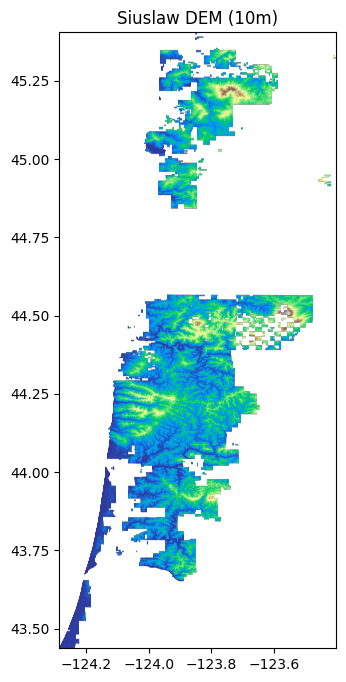

In [13]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

path = "/Users/colelacroix/Documents/siuslaw_dem_10m.tif"

src = rasterio.open(path)

print(src.crs)
print(src.width, src.height)
print(src.bounds)
print(src.count, "band(s)")

dem = src.read(1)  # elevation band as a numpy array
print(dem.shape, dem.dtype)
print("min/max elevation:", dem.min(), dem.max())

fig, ax = plt.subplots(figsize=(8, 8))
show(src, ax=ax, cmap="terrain")
plt.title("Siuslaw DEM (10m)")
plt.show()